In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Прочитайте данные (переменную назовите 'df')
df = pd.read_csv('data.csv')

# Вывести несколько первых строк таблицы данных
print(df.head())

         Дата  Склад Контрагент Номенклатура  Количество
0  2018-01-04      1  address_0    product_0           4
1  2018-01-04      1  address_0    product_1           4
2  2018-01-04      1  address_0    product_2           5
3  2018-01-04      1  address_0    product_3          10
4  2018-01-04      1  address_0    product_4           2


Проверяем формат столбцов

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301355 entries, 0 to 301354
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   Дата          301355 non-null  object
 1   Склад         301355 non-null  int64 
 2   Контрагент    301355 non-null  object
 3   Номенклатура  301355 non-null  object
 4   Количество    301355 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 11.5+ MB


Сразу переведем столбец "Дата" в правильный формат

In [4]:
df['Дата'] = pd.to_datetime(df['Дата'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301355 entries, 0 to 301354
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Дата          301355 non-null  datetime64[ns]
 1   Склад         301355 non-null  int64         
 2   Контрагент    301355 non-null  object        
 3   Номенклатура  301355 non-null  object        
 4   Количество    301355 non-null  int64         
dtypes: datetime64[ns](1), int64(2), object(2)
memory usage: 11.5+ MB


Сгруппируйте данные по дате, посчитайте количество продаж

In [5]:
grouped_df = df.groupby('Дата')['Количество'].sum().reset_index()

Вывести несколько первых строк сгруппированных данных

In [6]:
grouped_df.head(10)

,Дата,Количество
0,2018-01-04,3734
1,2018-01-05,3643
2,2018-01-06,3193
3,2018-01-07,3298
4,2018-01-09,4055
5,2018-01-10,3653
6,2018-01-11,3176
7,2018-01-12,3092
8,2018-01-13,3294
9,2018-01-14,3228


Нарисуйте график продаж у `grouped_df`

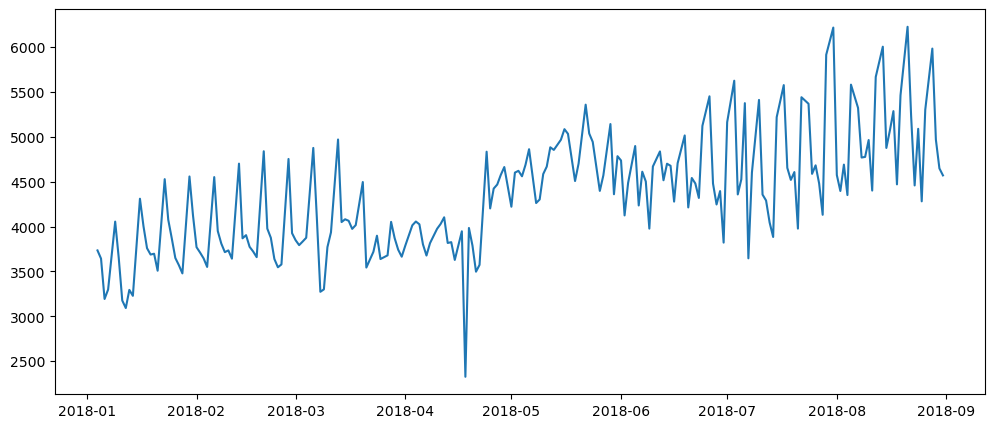

In [7]:
fig, ax1 = plt.subplots(figsize=(12, 5))
plt.plot(grouped_df['Дата'], grouped_df['Количество'])
plt.show()

Опишите что вы видите на графике. Ваша задача - максимально описать график

Вижу что у продаж сильная волотильность в зависимости от дня недели. Наблюдается резкое замедление и падение весной и в начале лето. Но в целом продажи растут.

Найдите строку, у которой максимальный выброс по количеству продаж (нужно найти выброс у `df`)

In [8]:
df_max = df.loc[df['Количество'].idxmax()]
df_max

Дата            2018-06-28 00:00:00
Склад                             1
Контрагент              address_208
Номенклатура              product_0
Количество                      200
Name: 218822, dtype: object

Найдите топовый товар по продажам по средам за июнь, июль, август у 3 склада

In [22]:
data_group = df.groupby(['Дата', 'Склад', 'Номенклатура'])['Количество'].sum().reset_index()
data_group.head()

,Дата,Склад,Номенклатура,Количество
0,2018-01-04,1,product_0,54
1,2018-01-04,1,product_1,107
2,2018-01-04,1,product_10,21
3,2018-01-04,1,product_11,10
4,2018-01-04,1,product_12,13


In [24]:
data_group_3 = data_group[(data_group['Склад'] == 3) & (data_group['Дата'] > '2018-05-31') & (data_group['Дата'] < '2018-09-01')]
wednesdays_group = data_group_3[data_group_3['Дата'].dt.dayofweek == 2]
wednesdays_total = wednesdays_group.groupby('Номенклатура')['Количество'].sum()

top_product = wednesdays_total.idxmax()
print(top_product, wednesdays_total.max())

product_1 2267


Скачайте данные по погоде с https://rp5.ru/Архив_погоды_в_Астане (скачайте исходные данные, и далее преобразуйте так, чтобы мы имели Дату и Среднюю температуру за день), объедините таблицу температуры с `grouped_df`, и нарисуйте график `y=['Количество продаж', 'T']`, где Т это температура. А также отдельно график температуры.

In [13]:
weather_ast = pd.read_csv('weather_astana.csv', encoding='utf-8', sep=';', skiprows=6, index_col=False)
weather_ast.head()

,Местное время в Астане,T,Po,P,Pa,U,DD,Ff,ff10,ff3,...,Cm,Ch,VV,Td,RRR,tR,E,Tg,E',sss
0,19.08.2018 23:00,16.4,722.5,752.5,-1.5,89.0,"Ветер, дующий с северо-северо-востока",1,NaN,NaN,...,NaN,NaN,NaN,14.5,0.6,12.0,NaN,NaN,NaN,NaN
1,19.08.2018 20:00,21.4,724.0,753.6,1.1,82.0,"Ветер, дующий с востоко-северо-востока",2,NaN,NaN,...,NaN,NaN,4.0,18.2,0.6,12.0,NaN,NaN,NaN,NaN
2,19.08.2018 17:00,23.1,722.9,752.3,-1.0,62.0,"Ветер, дующий с востока",3,NaN,NaN,...,"Высококучевых, высокослоистых или слоисто-дожд...","Перистых, перисто-кучевых или перисто-слоистых...",10.0,15.4,NaN,NaN,NaN,NaN,NaN,NaN
3,19.08.2018 14:00,22.4,723.9,753.4,-0.3,64.0,"Ветер, дующий с северо-северо-запада",4,NaN,NaN,...,"Высококучевых, высокослоистых или слоисто-дожд...","Перистых, перисто-кучевых или перисто-слоистых...",4.0,15.3,NaN,NaN,NaN,NaN,NaN,NaN
4,19.08.2018 11:00,22.2,724.2,753.7,-1.0,54.0,"Ветер, дующий с востоко-юго-востока",3,NaN,NaN,...,"Высококучевых, высокослоистых или слоисто-дожд...","Перистых, перисто-кучевых или перисто-слоистых...",10.0,12.5,NaN,NaN,NaN,NaN,NaN,NaN


In [14]:
weather_ast['Местное время в Астане'] = pd.to_datetime(weather_ast['Местное время в Астане'])
weather_ast.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1822 entries, 0 to 1821
Data columns (total 29 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Местное время в Астане  1822 non-null   datetime64[ns]
 1   T                       1822 non-null   float64       
 2   Po                      1822 non-null   float64       
 3   P                       1822 non-null   float64       
 4   Pa                      1819 non-null   float64       
 5   U                       1821 non-null   float64       
 6   DD                      1822 non-null   object        
 7   Ff                      1822 non-null   int64         
 8   ff10                    15 non-null     float64       
 9   ff3                     49 non-null     float64       
 10  N                       1821 non-null   object        
 11  WW                      1822 non-null   object        
 12  W1                      639 non-null    object  

C:\Users\Админ\AppData\Local\Temp\ipykernel_16920\1218851715.py:1: UserWarning: Parsing dates in %d.%m.%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  weather_ast['Местное время в Астане'] = pd.to_datetime(weather_ast['Местное время в Астане'])


In [15]:
weather_ast['Местное время в Астане'] = weather_ast['Местное время в Астане'].dt.normalize()
weather_ast = weather_ast.rename(columns={'Местное время в Астане': 'Дата'})
weather_ast.head()

,Дата,T,Po,P,Pa,U,DD,Ff,ff10,ff3,...,Cm,Ch,VV,Td,RRR,tR,E,Tg,E',sss
0,2018-08-19,16.4,722.5,752.5,-1.5,89.0,"Ветер, дующий с северо-северо-востока",1,NaN,NaN,...,NaN,NaN,NaN,14.5,0.6,12.0,NaN,NaN,NaN,NaN
1,2018-08-19,21.4,724.0,753.6,1.1,82.0,"Ветер, дующий с востоко-северо-востока",2,NaN,NaN,...,NaN,NaN,4.0,18.2,0.6,12.0,NaN,NaN,NaN,NaN
2,2018-08-19,23.1,722.9,752.3,-1.0,62.0,"Ветер, дующий с востока",3,NaN,NaN,...,"Высококучевых, высокослоистых или слоисто-дожд...","Перистых, перисто-кучевых или перисто-слоистых...",10.0,15.4,NaN,NaN,NaN,NaN,NaN,NaN
3,2018-08-19,22.4,723.9,753.4,-0.3,64.0,"Ветер, дующий с северо-северо-запада",4,NaN,NaN,...,"Высококучевых, высокослоистых или слоисто-дожд...","Перистых, перисто-кучевых или перисто-слоистых...",4.0,15.3,NaN,NaN,NaN,NaN,NaN,NaN
4,2018-08-19,22.2,724.2,753.7,-1.0,54.0,"Ветер, дующий с востоко-юго-востока",3,NaN,NaN,...,"Высококучевых, высокослоистых или слоисто-дожд...","Перистых, перисто-кучевых или перисто-слоистых...",10.0,12.5,NaN,NaN,NaN,NaN,NaN,NaN


In [16]:
avg_temp = weather_ast.groupby('Дата')['T'].mean().reset_index()
avg_temp.head()

,Дата,T
0,2018-01-04,-14.0750
1,2018-01-05,-16.8625
2,2018-01-06,-13.3000
3,2018-01-07,-12.7500
4,2018-01-08,-15.4125


In [17]:
merged = grouped_df.merge(avg_temp, left_on='Дата', right_on='Дата', how='left')
merged.head()

,Дата,Количество,T
0,2018-01-04,3734,-14.0750
1,2018-01-05,3643,-16.8625
2,2018-01-06,3193,-13.3000
3,2018-01-07,3298,-12.7500
4,2018-01-09,4055,-6.2500


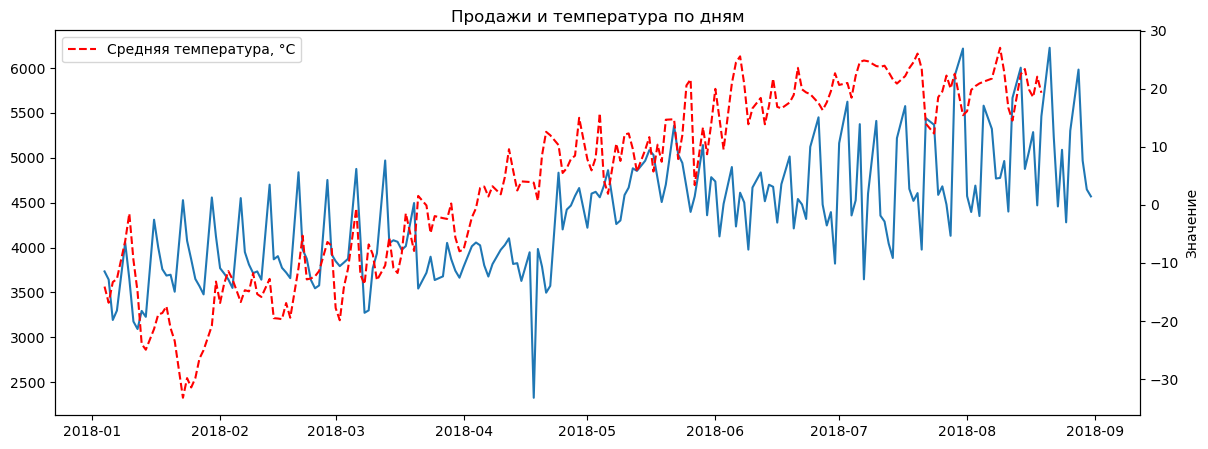

In [18]:
fig, ax1 = plt.subplots(figsize=(14, 5))
ax1.plot(merged['Дата'], merged['Количество'], label='Количество продаж, шт')
ax2 = ax1.twinx()
ax2.plot(merged['Дата'], merged['T'], color='red', linestyle='--', label='Средняя температура, °C')
plt.xlabel('Дата')
plt.ylabel('Значение')
plt.title('Продажи и температура по дням')
plt.legend()
plt.show()

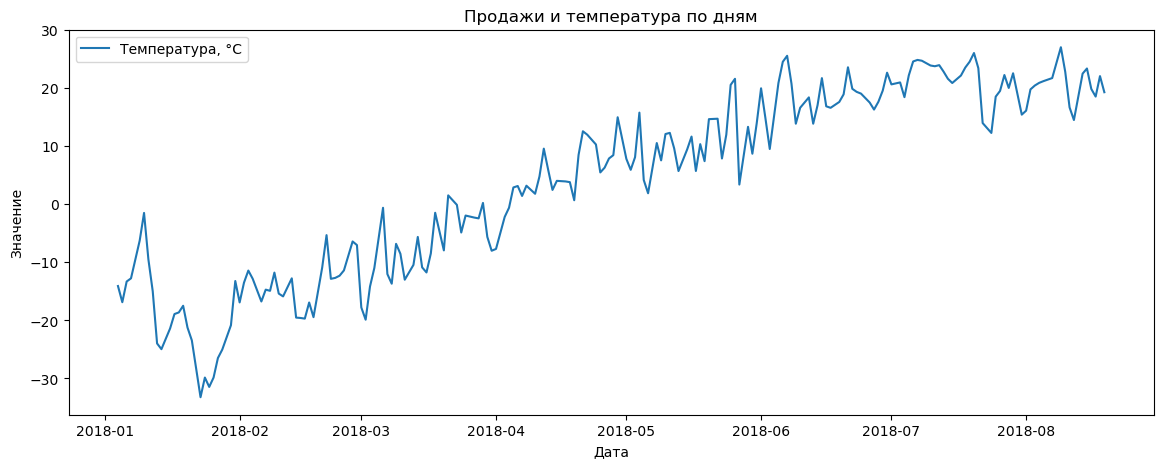

In [20]:
fig, ax1 = plt.subplots(figsize=(14, 5))
plt.plot(merged['Дата'], merged['T'], label='Температура, °C')
plt.xlabel('Дата')
plt.ylabel('Значение')
plt.title('Продажи и температура по дням')
plt.legend()
plt.show()